# Hello!

Here's a notebook that will walk you through a sample use-case you can run on your laptop!

In [8]:
# Import the goods
import sys
import gc
from tqdm import tqdm
from dataclasses import dataclass
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

from qtree.coupled_fluxonium import *
from qtree.branch_analysis_w_chain import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Setting some vals
f_trunc     = 25
ncut        = 25
osc_trunc   = 60
chain_trunc = 4
f_c         = 5
flux        = 0
lookup      = False
EJ  = 5
EL  = .1
EC  = 1
g_n = .12
g_phi = 1j * g_n
f_r = 6.6
coupling_type = 'capacitive'
chain_mode = True
fit_params = {}

EC_a = .0001
EJ_a = 20
cg_a = 1e-6
c_a  = 1e-6
num_JJ = 204
g_chain = get_g_chain(EJ, EC_a, EJ_a, cg_a, c_a, num_JJ, chain_trunc)
print(g_chain)

# This may be excessive but it feels more flexible
# if things need to change
var_list = ['f_trunc', 'ncut', 'osc_trunc', 'flux', 'lookup', 'EJ', 'EL', 'EC', 'g_n', 'g_phi', 'f_r', 
            'coupling_type', 'chain_mode', 'f_c', 'chain_trunc', 'g_chain']

units = {'flux': r"$\Phi_0$"}
_locals = locals()

fit_params.update({
    name: (_locals[name], units.get(name), None)
    for name in var_list
})

In [ ]:
# Gather up eigenvectors/values and Hamiltonian
dat_package, H_full = get_objs(fit_params, 'fluxonium')

In [ ]:
# Perform and batch branch analysis
res = branch_analysis(dat_package, update_flux=False)
params, data = res

In [ ]:
# Grab all interesting keys
key_list = []
key_list_r = []
for key in data.keys():
    if 'n_q_branch' in key:
        key_list.append(key)
        key_list_r.append(key.replace('q', 'r'))

In [ ]:
# Generate plots ala Alexandre Blais' papers
for key, key_r in zip(key_list, key_list_r):
    plt.plot(data[key][0], label=key)
plt.xlim(1, osc_trunc-2)
plt.ylim(0, 20)
plt.title('MIST in Fluxonium with Chain Modes', fontsize=15)
plt.xlabel(r'$\langle n_r \rangle$', fontsize=15)
plt.ylabel(r'$\langle n_q \rangle$', fontsize=15)
plt.legend()
plt.savefig('../figures/sample.jpg')
plt.show()

In [ ]:
# Perform the same work as a function of flux
flux_arr = np.linspace(-.1, .6, 80)
res_list = []
for flux in tqdm(flux_arr, ascii=True, desc="sweeping flux..."):
    
    fit_params['flux'] = (flux, r'$\Phi_0$', None)
    dat_package, H_full = get_objs(fit_params, 'fluxonium', H_full,
                           update_flux=True)
    res = branch_analysis(dat_package, update_flux=True)
    res_list.append(res)
    del dat_package
    gc.collect()

In [ ]:
# Re-package things to make plotting easier
big_dat_list0 = []
big_dat_list1 = []

for res in res_list:
    params, data, params_list, data_list, branches, dressed_evals, dressed_evecs = res
    l0 = data_list[0]['n_q'][0]
    l1 = data_list[1]['n_q'][0]
    big_dat_list0.append(np.asarray(l0))
    big_dat_list1.append(np.asarray(l1))

In [ ]:
# Trimming off the edge of the Hilbert space
mist0 = np.asarray(big_dat_list0).T[:-5]
mist1 = np.asarray(big_dat_list1).T[:-5]

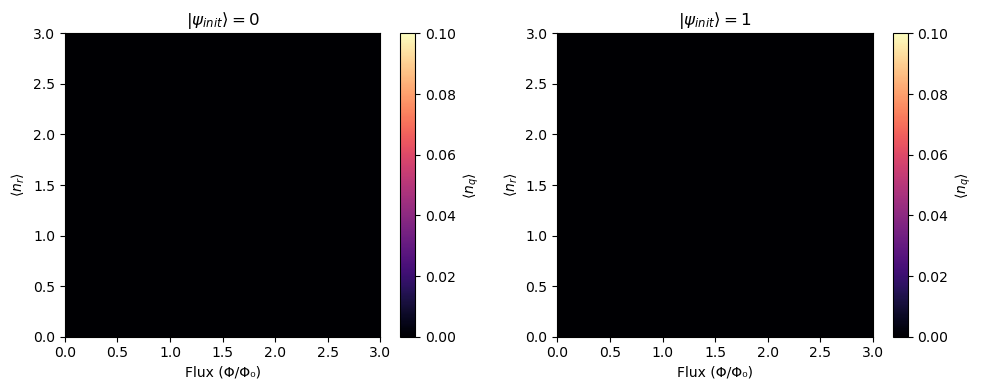

In [35]:
# Create a plot of the flux sweep
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
extent = [flux_arr[0], flux_arr[-1], n_r_list[0], n_r_list[-1]]

im0 = ax[0].imshow(mist0, extent=extent, aspect='auto', 
                   cmap='magma', vmin=0, vmax=.1)

im1 = ax[1].imshow(mist1, extent=extent, aspect='auto', 
                   cmap='magma', vmin=0, vmax=.1)
    
plt.colorbar(im1, label=r'$⟨n_q⟩$', ax = ax[1])
plt.colorbar(im0, label=r'$⟨n_q⟩$', ax = ax[0])

ax[0].set_title(r'$|\psi_{init}\rangle=0$')
ax[0].set_xlabel('Flux (Φ/Φ₀)')
ax[0].set_ylabel(r'$⟨n_r⟩$')
ax[1].set_title(r'$|\psi_{init}\rangle=1$')
ax[1].set_xlabel('Flux (Φ/Φ₀)')
ax[1].set_ylabel(r'$⟨n_r⟩$')

plt.tight_layout()
plt.show()

# Using Cluster Data

In [ ]:
# Load sample data
filename = r"../sample_data/sample_fluxonium.pkl"
with open(filename, "rb") as f:
    dat_0 = pkl.load(f)

In [ ]:
# Write out strings for keys/titles of subplots
key_list = ['n_q_branch=q0_c0', 'n_q_branch=q0_c1', 'n_q_branch=q0_c2', 'n_q_branch=q0_c3']
name_list = [r'$⟨n_c⟩ = 0$', r'$⟨n_c⟩ = 1$', r'$⟨n_c⟩ = 2$', r'$⟨n_c⟩ = 3$']

In [ ]:
# Check out the array mode effects
step =.005
flux_arr = np.arange(-.1, .6, step)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
n_r_list = np.arange(0, 60, 1)
extent = [-.1, .6, 0, 60]

for ax, key, name in zip(axes, key_list, name_list):
    ax.set_title(name)
    ax.set_xlabel('Flux (Φ/Φ₀)')
    ax.set_ylabel(r'$⟨n_r⟩$')
    fixed = Z_fixed = np.flipud(dat_0[key].T)

    im = ax.imshow(fixed, extent=extent, cmap='magma', vmin=0, vmax=4)
    ax.set_ylim(0, 55)
    ax.set_aspect("auto")

    plt.colorbar(im, ax = ax)

title = r'$\Psi_{init} = |0⟩$'
fig.suptitle(title, fontsize=16)
plt.tight_layout()
plt.savefig(r'example_ground_w_array_mode.png')
plt.show()